# II.2

### Q4

100%|██████████| 50000/50000 [00:45<00:00, 1109.76it/s]


AttributeError: module 'numpy' has no attribute 'atan2'

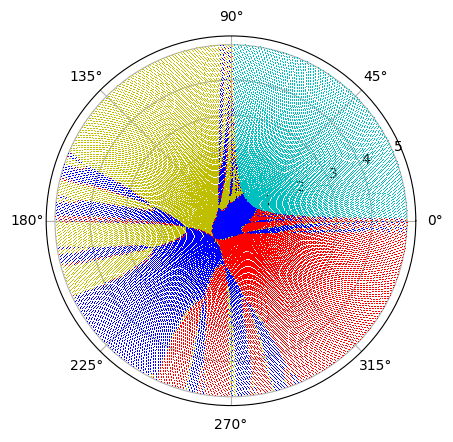

In [1]:
import numpy as np, matplotlib.pyplot as plt, tqdm

def Newton(F, J, x0, tol, max=10**60, maxiterations=10**6):
    x = x0
    i = 0
    while tol < np.linalg.norm(F(x)) < max and i < maxiterations:
        x = x + np.linalg.solve(J(x), -F(x))
        i+=1
        #print(np.linalg.norm(F(x)))
        #print(x)
    if np.linalg.norm(F(x)) <= tol:  return ({"x":x, "iterations":i, "converges":True})
    else: return({"x":None, "iterations":"oo", "converges":False})

def F1(x):   return np.array([x[0]**2 - x[1] - 1, x[0] - x[1]**2 + 1])
def J1(x):   return np.array([[2*x[0],-1], [1,-2*x[1]]])

#print(Newton(F1, J1, np.array([0,0.5]), 10**-8))

def hunt(F, J, tests, tol=10**-8, r=0.1, theta=0.5, decimals=5, graph="solutions", max=10**60, maxiterations=10**6):
    fig = plt.figure()
    ax = plt.subplot(projection="polar")
    colours = ['b', 'y', 'r', 'c', 'm', 'g', 'k', 'w']

    solutions = []
    start = np.array([0,0])

    for i in tqdm.tqdm(range(tests)):
        #print(start)
        test = Newton(F, J, start[0]*np.array([np.cos(start[1]),np.sin(start[1])]), tol, max=max, maxiterations=maxiterations)
        if not test["converges"]:   solution="diverges"
        else:   solution = (np.round(test["x"], decimals)[0], np.round(test["x"], decimals)[1])
        
        if solution not in solutions: solutions.append(solution)

        if graph=="solutions":   plt.polar(start[1], start[0], colours[solutions.index(solution)]+",")
        else:
            j=test["iterations"]
            if j=="oo":  plt.polar(start[1], start[0], color=(0, 1, 0), marker="o")
            else:   plt.polar(start[1], start[0], color=(np.log(j+1)/np.log(maxiterations), 0, 1-np.log(j+1)/np.log(maxiterations)), marker="o")

        start = start + np.array([r, theta])

    for i in solutions:
        if i!="diverges":   plt.plot(np.atan2(i[1], i[0]), (i[0]**2 + i[1]**2)**0.5, colours[solutions.index(i)]+"x", label=str((float(i[0]),float(i[1]))))

    fig.legend()
    plt.gcf().set_dpi(300)
    plt.tight_layout()
    plt.show()
    #return solutions


hunt(F1, J1, 50000, r=0.0001)

### Q5

a) The minimum is $E=0$ at $(1,1)$

b) $\nabla E = (-2(1-x) - 400x(y-x^2), 200(y-x^2)) = (400x^3 - 400xy + 2x - 2, 200y - 200x^2)$

100%|██████████| 100/100 [00:00<00:00, 3664.20it/s]


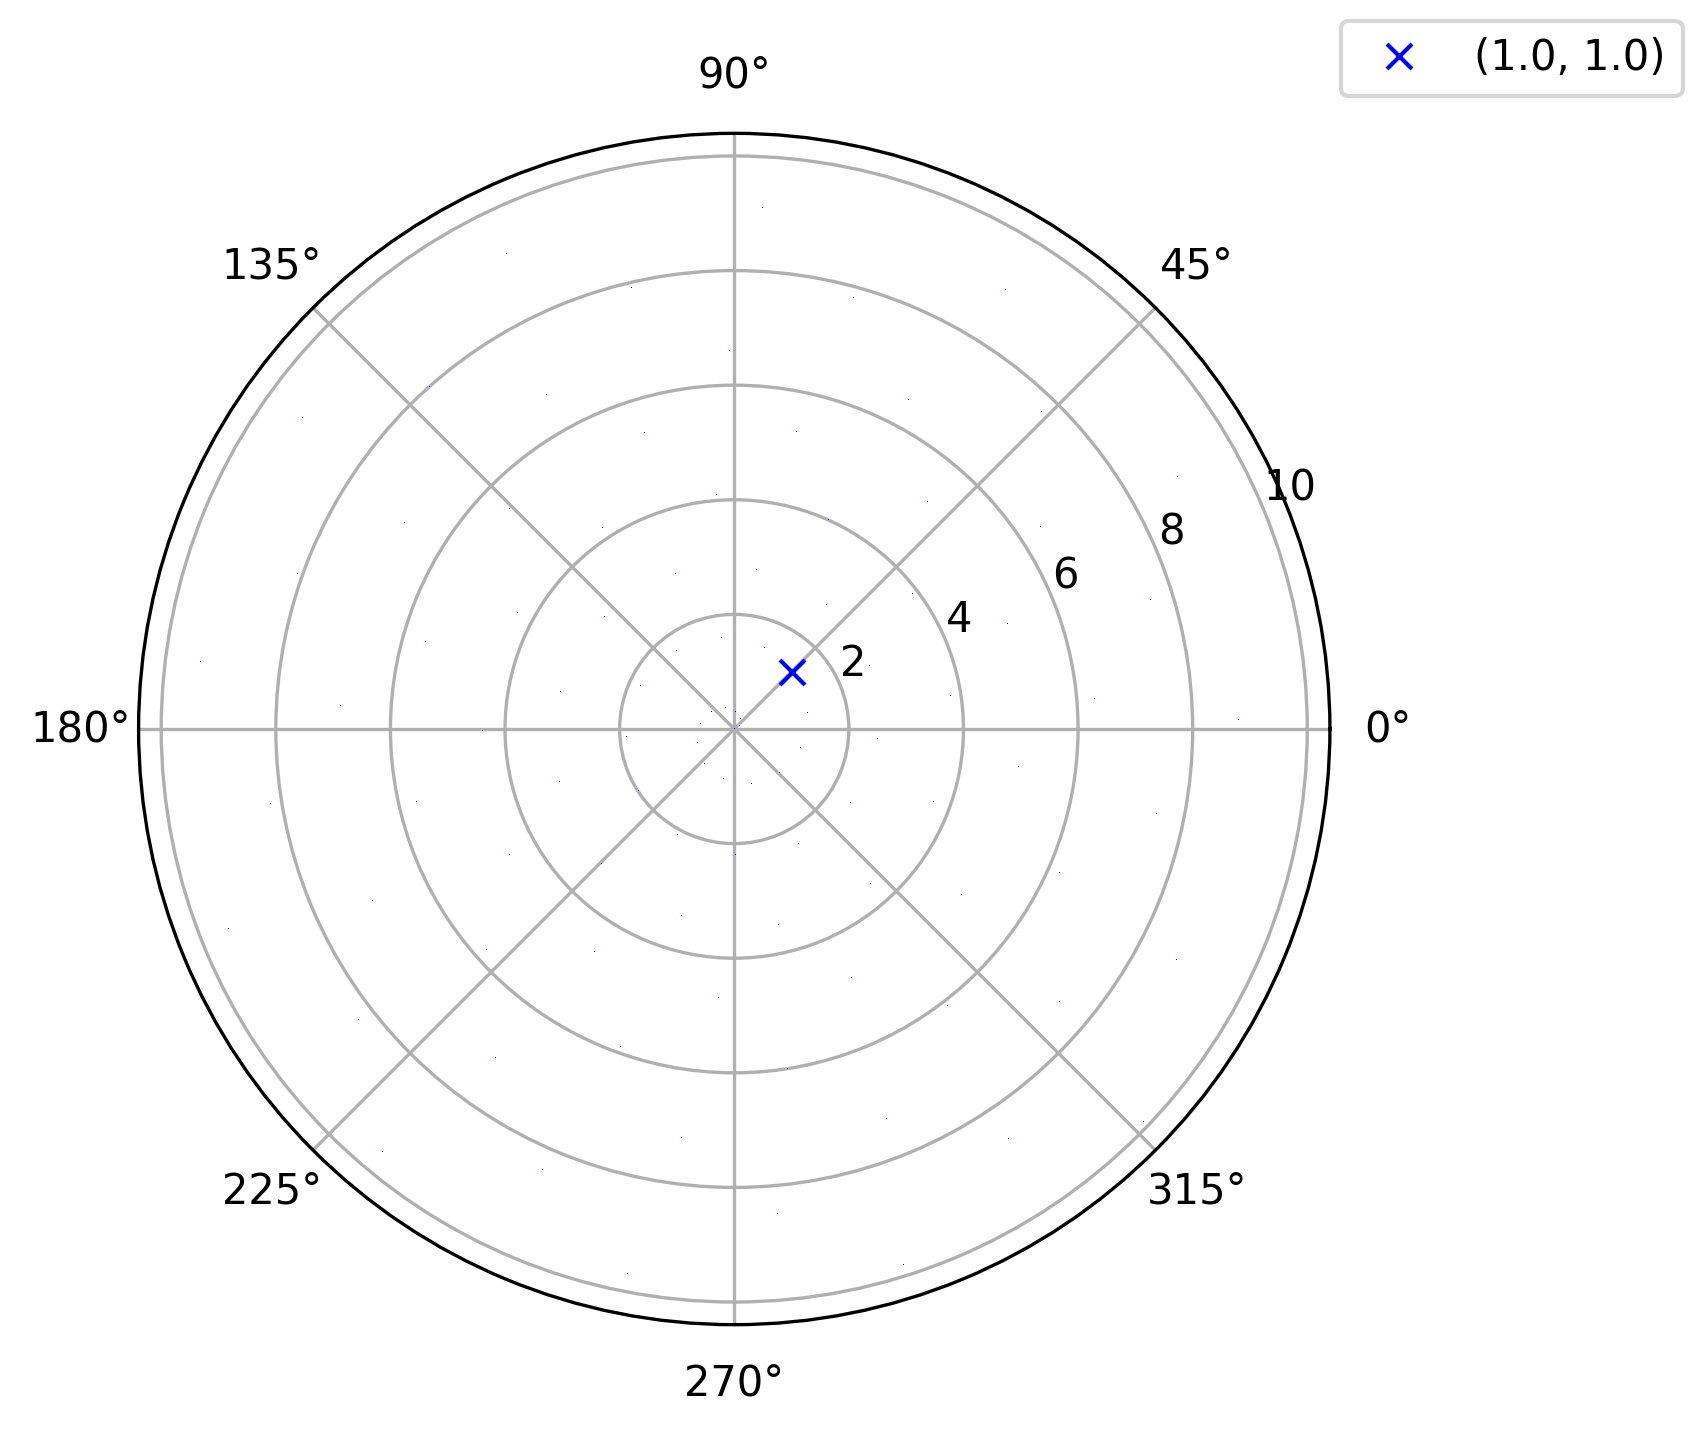

In [ ]:
def F2(x): return np.array([400*x[0]**3 - 400*x[0]*x[1] + 2*x[0] - 2, 200*x[1] - 200*x[0]**2])
def J2(x): return np.array([[1200*x[0]**2 - 400*x[1] + 2, -400*x[0]],[-400*x[0], 200]])

hunt(F2, J2, 100)

In [ ]:
for test in [np.array([2,2]), np.array([10,10]), np.array([100,100])]:  print(f"({test[0]}, {test[1]}) took {Newton(F2, J2, test, 10**-8)['iterations']} iterations")

(2, 2) took 5 iterations
(10, 10) took 5 iterations
(100, 100) took 5 iterations


In [ ]:
for alpha in [1000, 500, 2000]:  print(f"alpha={alpha} took {Newton(F2, lambda x: np.array([[alpha,0],[0,alpha]]), np.array([2,2]), 10**-8)['iterations']} iterations")

alpha=1000 took 43802 iterations
alpha=500 took oo iterations
alpha=2000 took 91661 iterations


100%|██████████| 1000/1000 [00:00<00:00, 5830.22it/s]


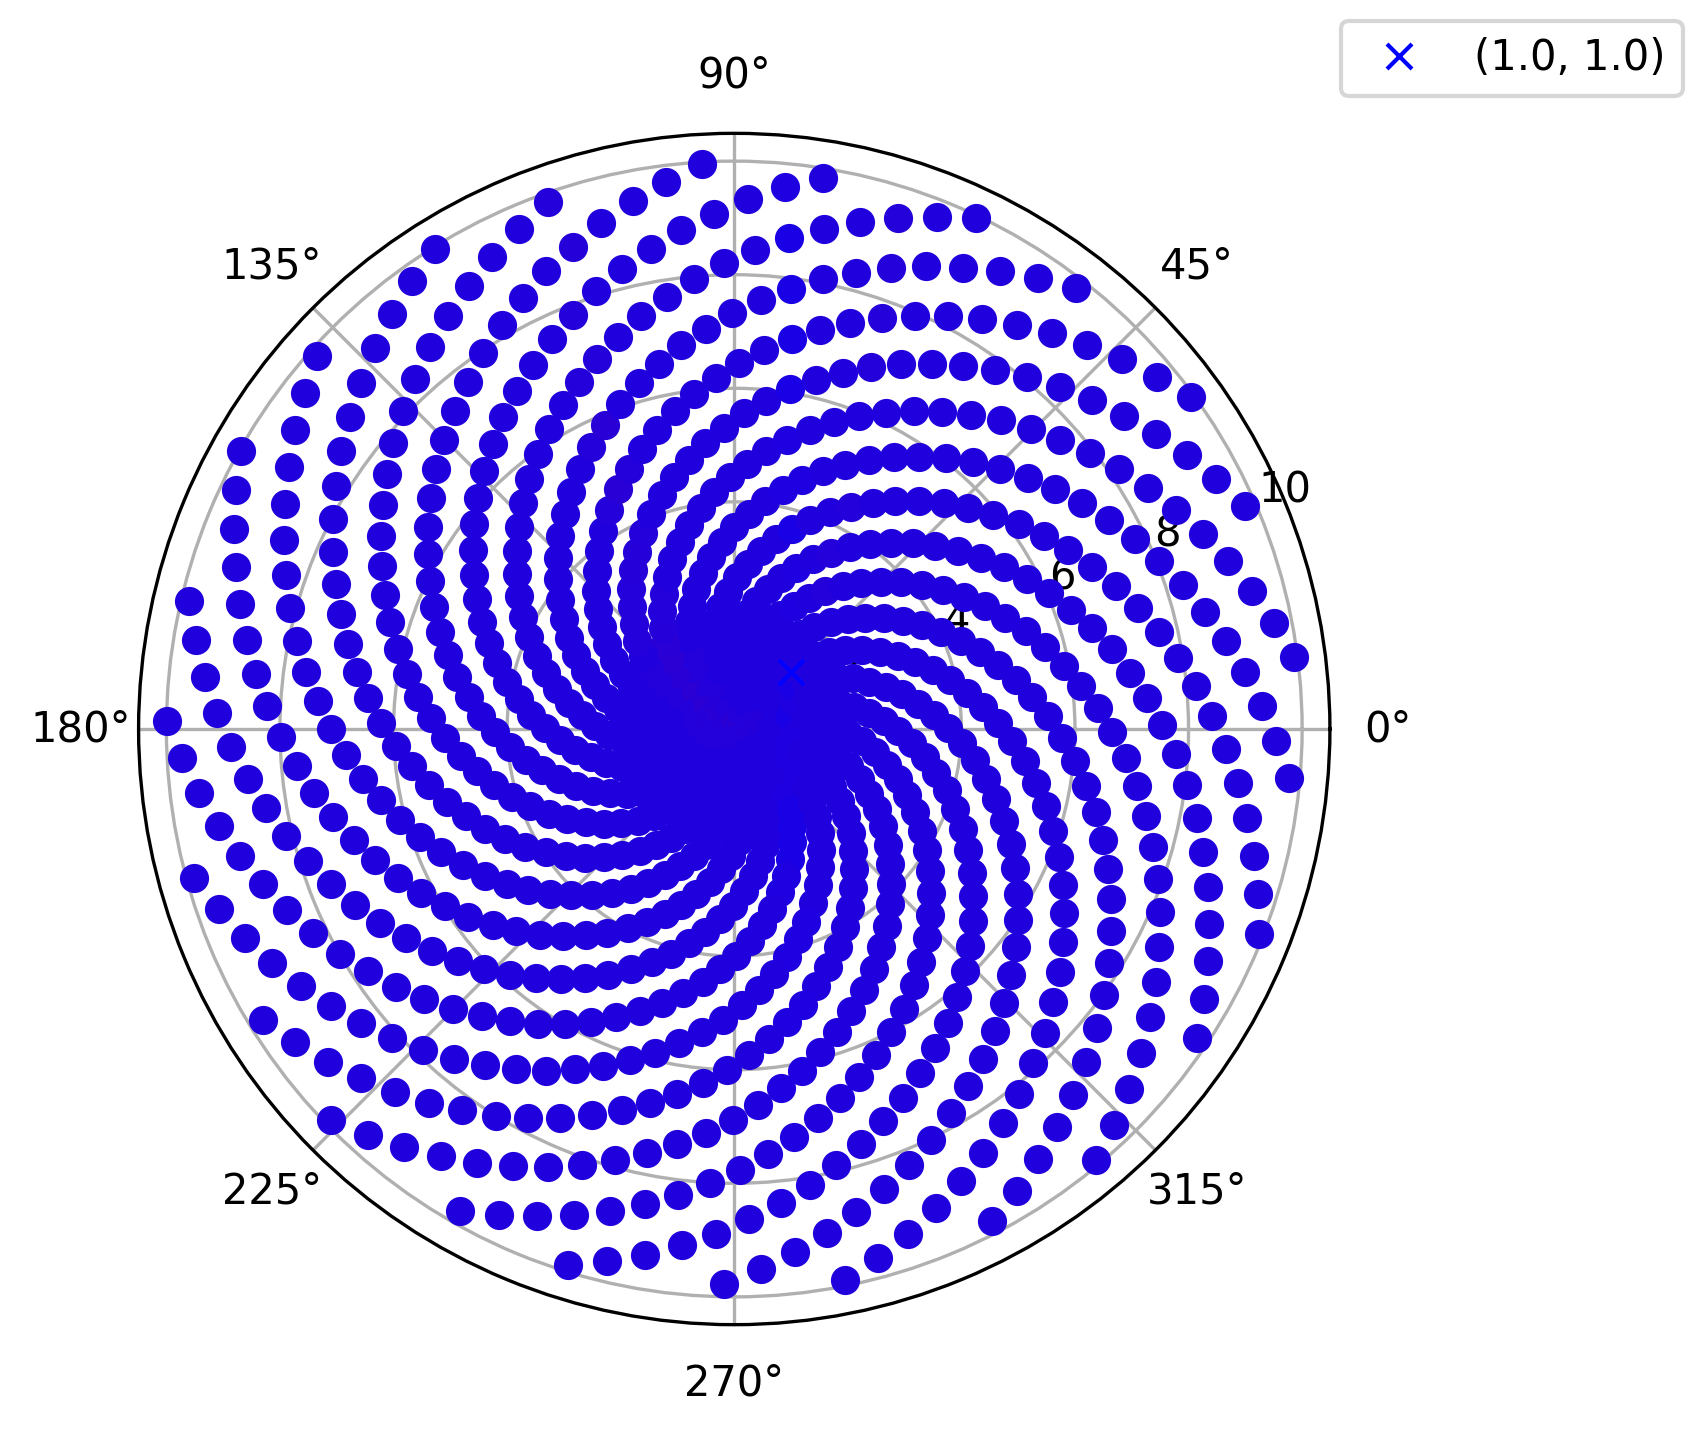

100%|██████████| 100/100 [00:09<00:00, 10.02it/s]


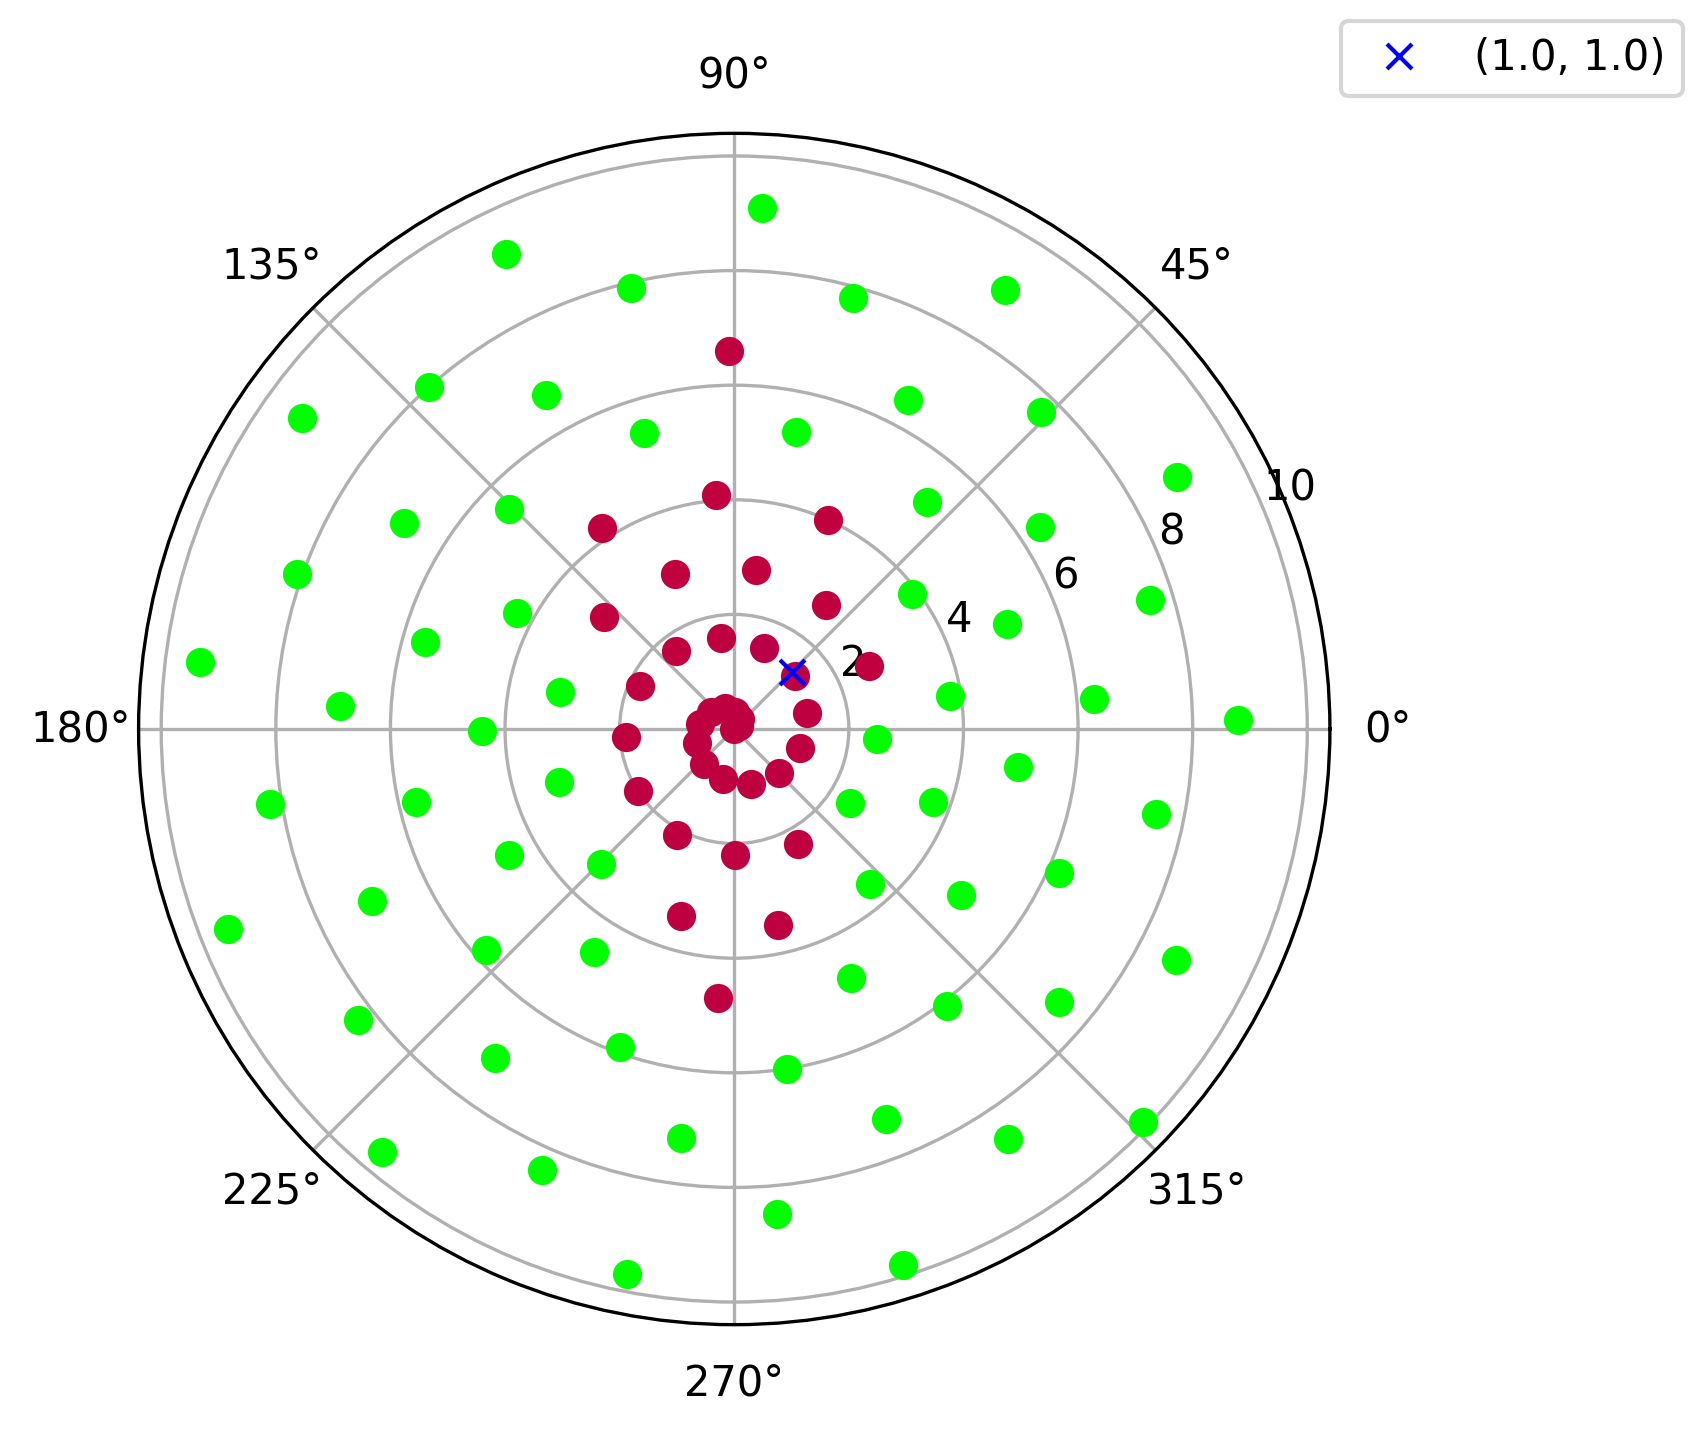

100%|██████████| 100/100 [03:10<00:00,  1.90s/it]
/var/folders/55/n84b8nbd2ybgnrf6zqr4kyc00000gn/T/ipykernel_12060/490588143.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()


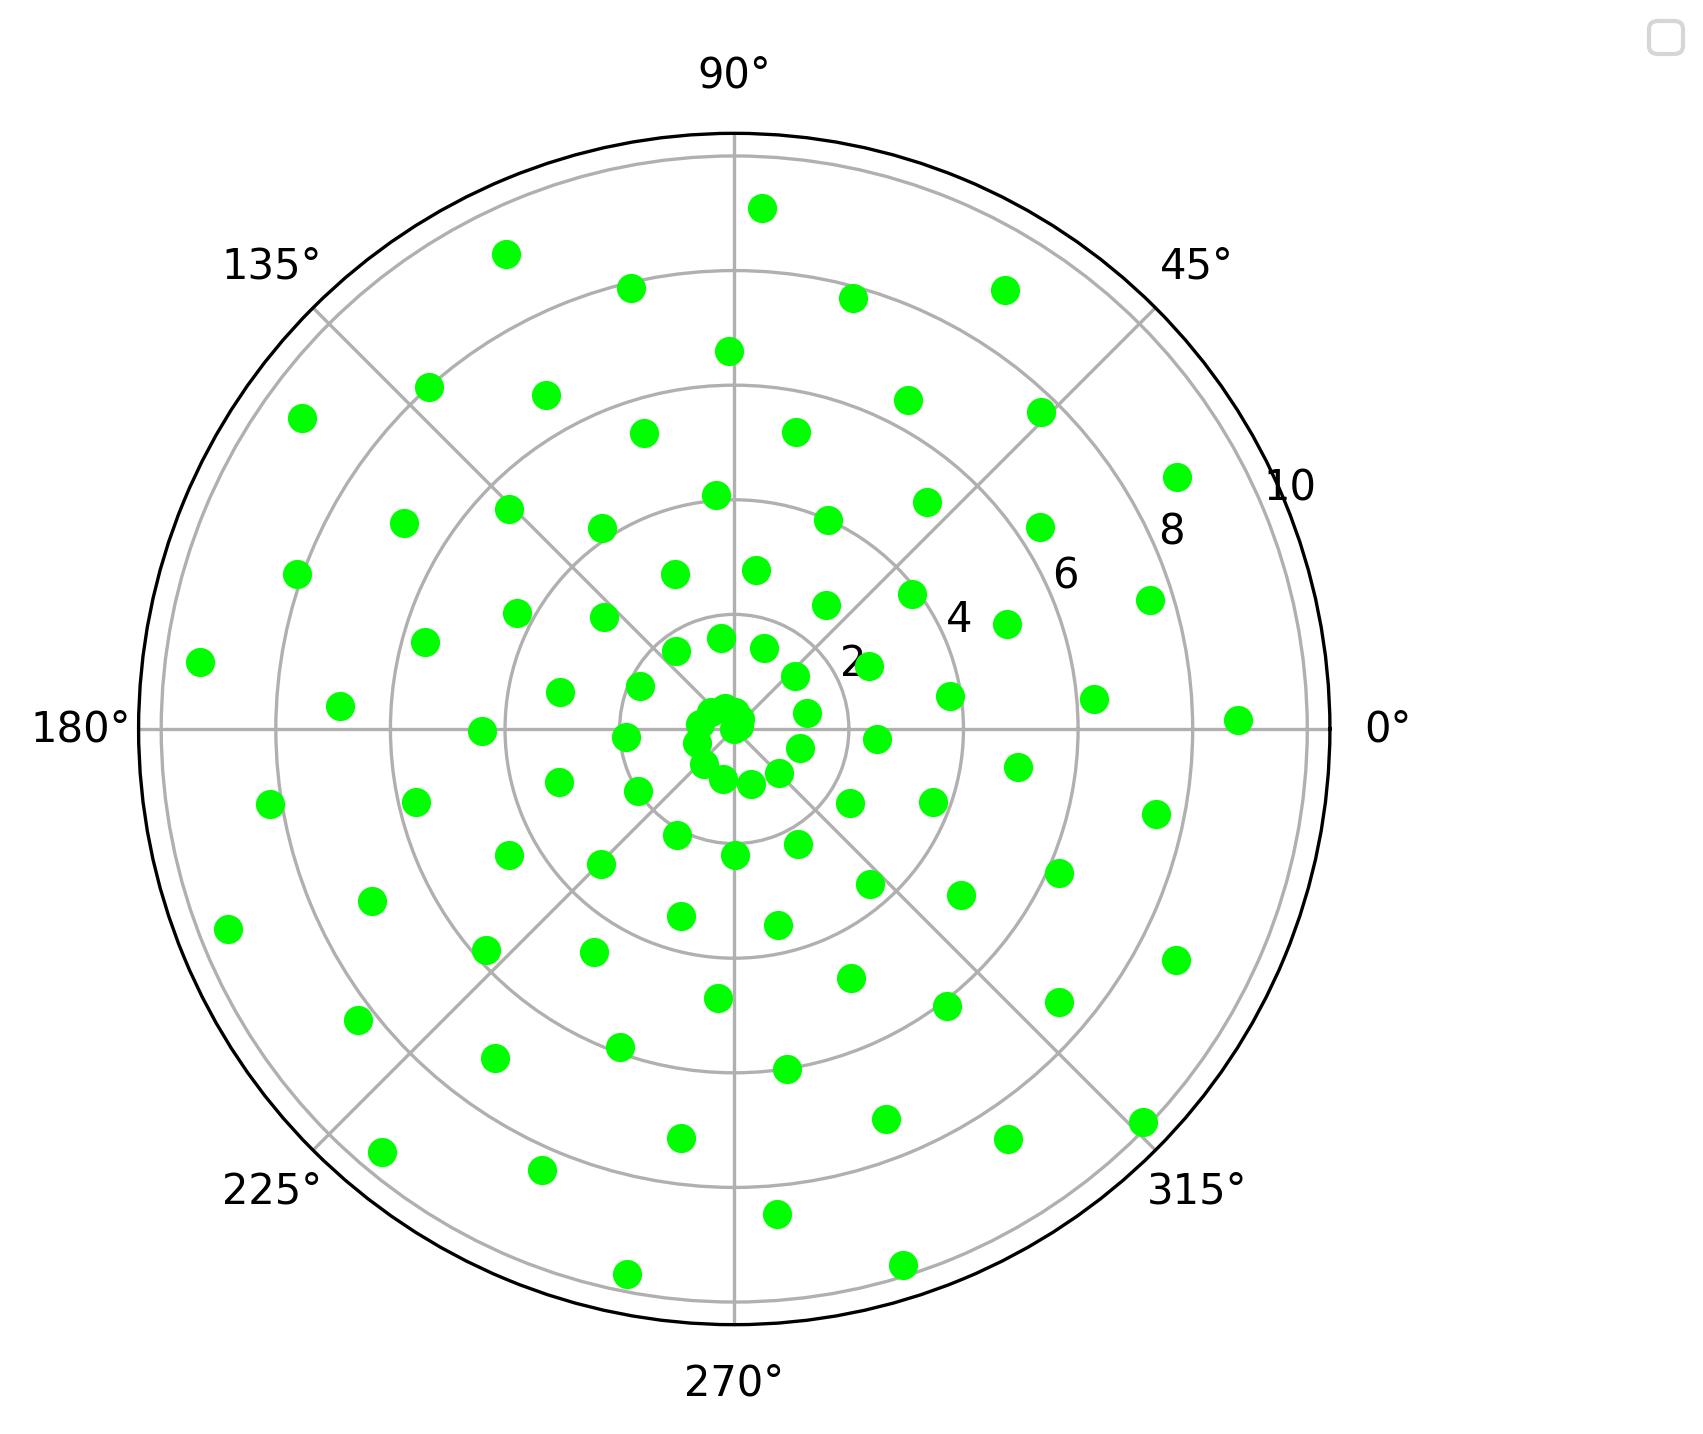

100%|██████████| 100/100 [00:31<00:00,  3.22it/s]


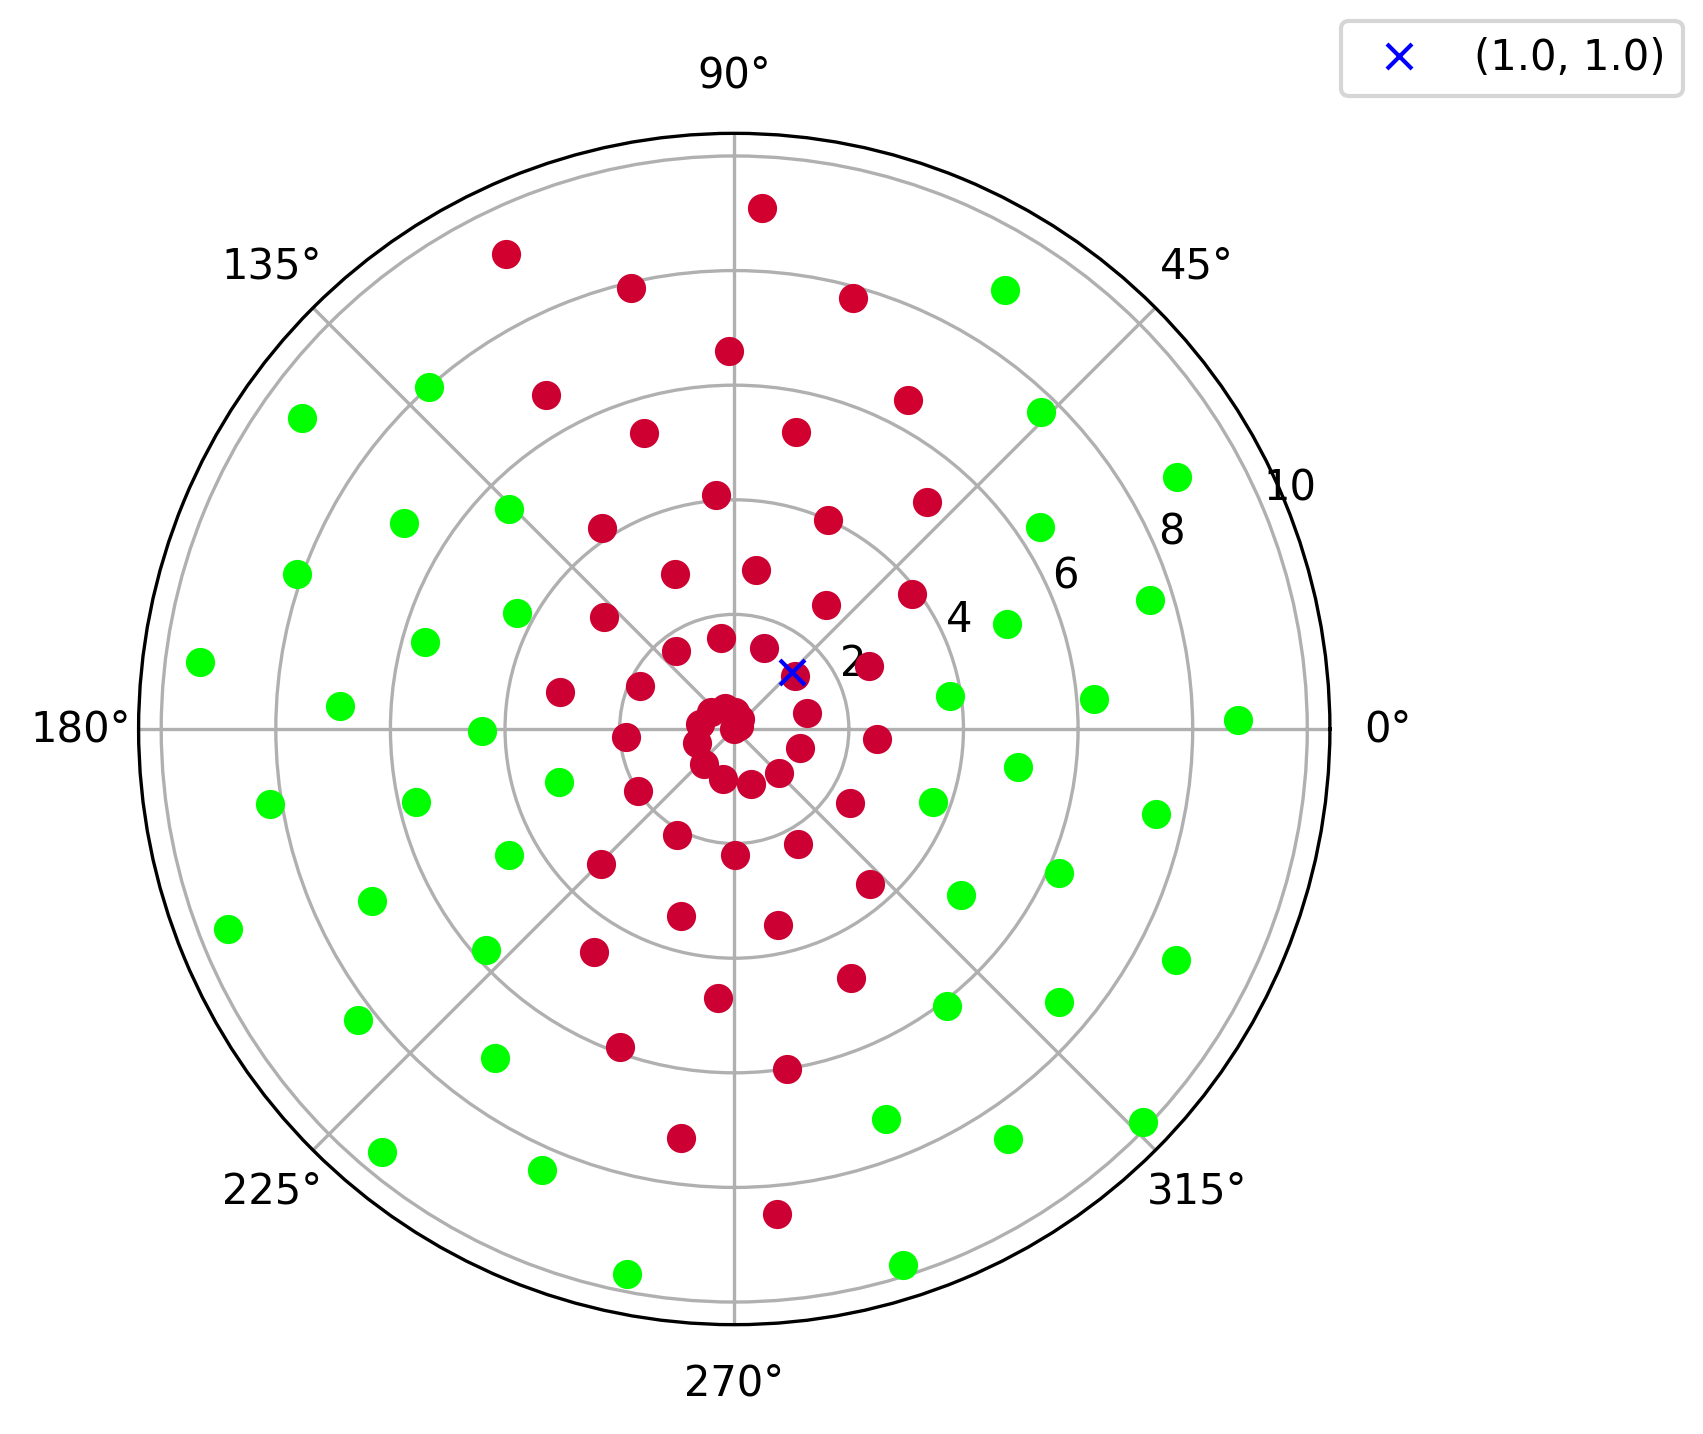

In [ ]:
hunt(F2, J2, 1000, r=0.01, graph="")
for alpha in [1000, 500, 2000]:  hunt(F2, lambda x: np.array([[alpha,0],[0,alpha]]), 100, r=0.1, graph="", tol=10**-6, maxiterations=10**6)

The first graph is how quickly the Newton method converges for the system; the following graphs are how quickly the gradient descent method converges for $alpha = 1000,500,200$

Blue-red is fast-slow convergence, green means the method diverged (or did not converge within $10^6$ iterations)